In [1]:
print('all ok')

all ok


In [2]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [3]:
GROQ_API_KEY=os.getenv("GROQ_API_KEY")

In [4]:
if not GROQ_API_KEY:
   raise ValueError("Groq api key is missing in your .env")
os.environ["GROQ_API_KEY"]=GROQ_API_KEY

In [5]:
from langchain_groq import ChatGroq

In [6]:
chat_llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.3
)


In [7]:
chat_llm.invoke("Hello how are you ?").content

"I'm just a computer program, so I don't have feelings, but thank you for asking. I'm functioning properly and ready to help with any questions or tasks you may have. How can I assist you today?"

In [8]:
from typing_extensions import TypedDict, Annotated
import operator

In [9]:
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage

In [10]:
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [11]:
{
    "messages": [HumanMessage(content="Hi, this is Sunny. Say hello in detail.")]
}

{'messages': [HumanMessage(content='Hi, this is Sunny. Say hello in detail.', additional_kwargs={}, response_metadata={})]}

In [12]:
["hi"]

['hi']

In [13]:
["hi","how are you?"]

['hi', 'how are you?']

In [14]:
def llm_call(state: GraphState) -> dict:
    """Call the LLM using conversation messages and append AI response."""
    response = chat_llm.invoke(state["messages"])  # AIMessage
    return {
        "messages": [response]
    }

In [15]:
def token_counter(state: GraphState) -> dict:
    """Count tokens (simple word count) in the last AI message."""
    last_msg = state["messages"][-1]
    text = last_msg.content
    token_number = len(text.split())
    summary = f"Total token number in the generated answer (word count) is {token_number}"
    return {
        "messages": [AIMessage(content=summary)]
    }

In [16]:

from langgraph.graph import StateGraph

In [17]:

builder = StateGraph(GraphState)

In [18]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [19]:

builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

In [20]:

app = builder.compile()

In [21]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [22]:

from IPython.display import Image, display

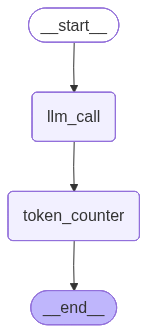

In [23]:
display(Image(app.get_graph().draw_mermaid_png()))

In [24]:
result = app.invoke({
    "messages": [HumanMessage(content="Hi, this is Rohit. what is Agentic AI? ")]
})

In [25]:

result

{'messages': [HumanMessage(content='Hi, this is Rohit. what is Agentic AI? ', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Hello Rohit, nice to meet you. Agentic AI refers to a type of artificial intelligence (AI) that is designed to exhibit autonomous behavior, similar to that of an agent in a social or physical environment. The term "agentic" comes from the concept of agency, which is the ability of an entity to act independently and make decisions based on its own goals, intentions, and motivations.\n\nAgentic AI systems are typically designed to be proactive, meaning they can initiate actions and take the lead in a situation, rather than simply reacting to external stimuli. They often have a sense of self-awareness, autonomy, and the ability to learn from their experiences.\n\nSome key characteristics of agentic AI include:\n\n1. **Autonomy**: Agentic AI systems can operate independently, making decisions without direct human intervention.\n2. **Self-awareness*

In [26]:
for m in result["messages"]:
    print(type(m).__name__, ":", m.content)

HumanMessage : Hi, this is Rohit. what is Agentic AI? 
AIMessage : Hello Rohit, nice to meet you. Agentic AI refers to a type of artificial intelligence (AI) that is designed to exhibit autonomous behavior, similar to that of an agent in a social or physical environment. The term "agentic" comes from the concept of agency, which is the ability of an entity to act independently and make decisions based on its own goals, intentions, and motivations.

Agentic AI systems are typically designed to be proactive, meaning they can initiate actions and take the lead in a situation, rather than simply reacting to external stimuli. They often have a sense of self-awareness, autonomy, and the ability to learn from their experiences.

Some key characteristics of agentic AI include:

1. **Autonomy**: Agentic AI systems can operate independently, making decisions without direct human intervention.
2. **Self-awareness**: They have a sense of their own existence, goals, and motivations.
3. **Proactivit

In [27]:
chat_llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001EE401E1610>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001EE414512B0>, model_name='llama-3.1-8b-instant', temperature=0.3, model_kwargs={}, groq_api_key=SecretStr('**********'))

In [28]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [29]:
api_wrapper=WikipediaAPIWrapper(top_k_results=5,doc_content_chars_max=500)

In [30]:
wiki_tool=WikipediaQueryRun(api_wrapper=api_wrapper)

In [31]:
wiki_tool.run({"query":"doraemon"})

c:\Users\Rohit\Desktop\Agentic_AI\agent_AI\Lib\site-packages\wikipedia\wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("lxml"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file c:\Users\Rohit\Desktop\Agentic_AI\agent_AI\Lib\site-packages\wikipedia\wikipedia.py. To get rid of this warning, pass the additional argument 'features="lxml"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')


"Page: Doraemon\nSummary: Doraemon (ドラえもん) is a Japanese manga series written and illustrated by Fujiko F. Fujio. First serialized in 1969, the manga's chapters were collected in 45 tankōbon volumes published by Shogakukan from 1974 to 1996. The story revolves around an earless robotic cat named Doraemon, who travels back in time from the 22nd century to assist a boy named Nobita Nobi in his day-to-day life.\nThe manga spawned a media franchise. It was adapted into three different anime TV series i"

In [35]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
#print(f"API Key: {TAVILY_API_KEY}")

In [ ]:
#tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

In [ ]:
#tool.invoke({"query":"what is the latest news about gen AI ?"})

[{'title': 'GenAI Today - News Portal',
  'url': 'https://www.genaitoday.ai/',
  'content': "Gen-AI-Today\n\n## GenAI Today News\n\n### What enterprises learn from mixed open model stacks\n\nEnterprises are done waiting for a single model to solve every problem. The most…  \n1/23/2026\n\n### Achieving Predictability at Scale: How AI and Automation is Transforming IT Operations\n\nAchieve predictability at scale by leveraging multi-domain agentic workflows tha…  \n12/22/2025\n\n### Enhancing Labor Productivity in Construction with AI Field Feedback Loops\n\nIn the competitive construction industry, leveraging Drawer AI-powered field fee…  \n12/15/2025\n\n### Icons8 Icons: an engineering-grade playbook\n\nIcons are functional parts of the interface. They compress intent, telegraph sta…  \n11/19/2025\n\n## More News\n\n### What enterprises learn from mixed open model stacks [...] GenAI Product of the Year Award winners demonstrate exceptional ability to transform workflows, accelerate dec

In [38]:
from langchain_community.tools import DuckDuckGoSearchRun
search=DuckDuckGoSearchRun()

In [39]:
search.invoke("what is latest update about the AI Submit ?")

Impersonate 'chrome_120' does not exist, using 'random'


"LIVE AI Impact Summit 2026 Live: Final Day Begins After Event Extended Till Feb 21, Check Latest Updates Here AI Summit 2026 Live Updates : Prime Minister Narendra Modi inaugurated the India AI Impact Summit 2026 in New Delhi, highlighting India's ambition to emerge as a global artificial intelligence powerhouse focused on responsible innovation and human-centric technology. Follow Times Now ... India AI Impact Summit 2026 LIVE Updates : PM Modi inaugurates the global AI Expo at Bharat Mandapam New Delhi. Track key speeches, announcements on AI policy, job disruption concerns, child safety discussions, traffic advisories, and major highlights from the high-profile event on republicworld.com The India AI Impact Summit 2026 in New Delhi brings together global political leaders, technology giants, startups, and researchers to deliberate on Delhi AI Summit 2026 Highlights: Prime Minister Narendra Modi spoke at the opening ceremony of India AI Impact Summit on 19 February, Thursday. During